# A Review of HABOTEST HT-820 Infrared Thermal Imaging Camera

Here's a review of a cheap thermal camera I obtained on AliExpress. My plan is to use it for PCB inspection and home insulation inspection.

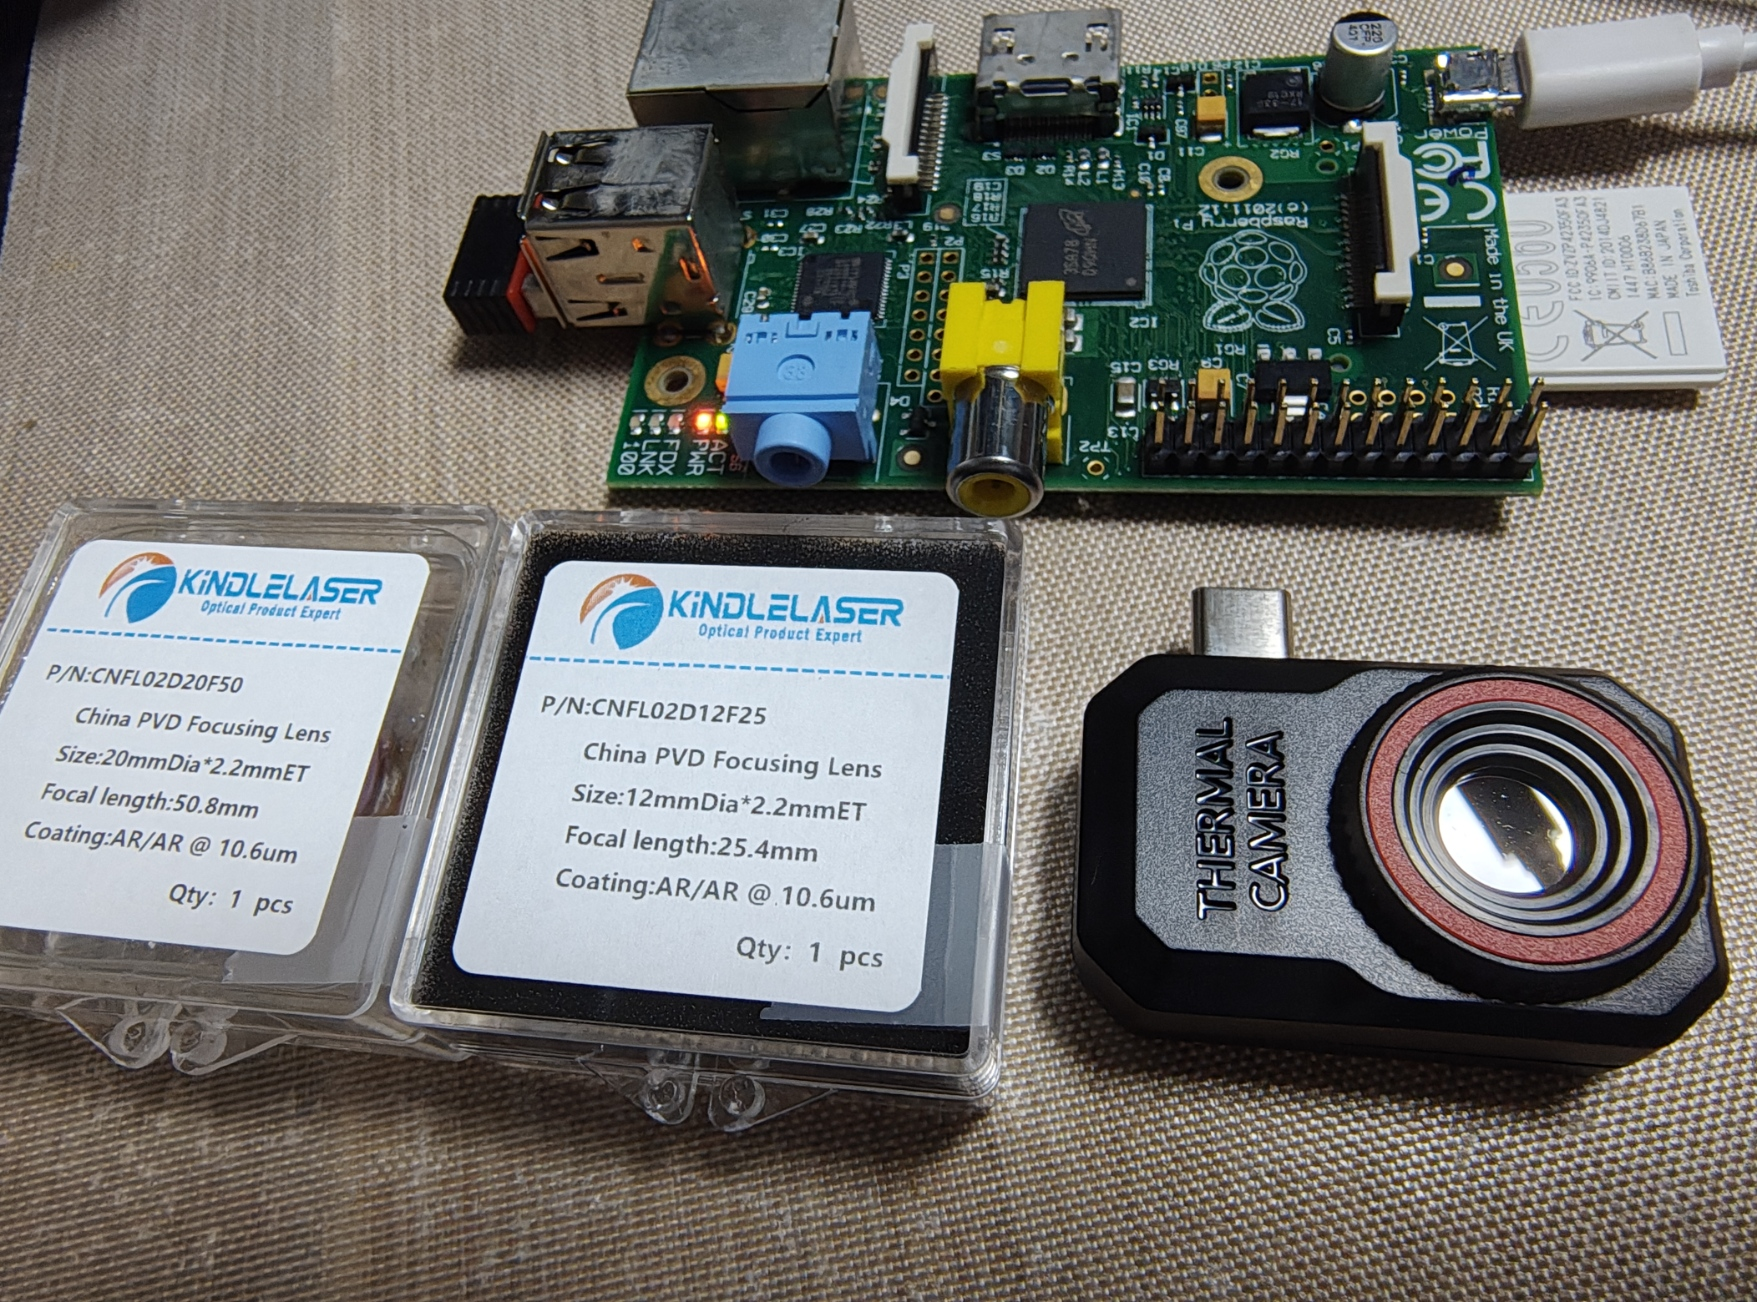

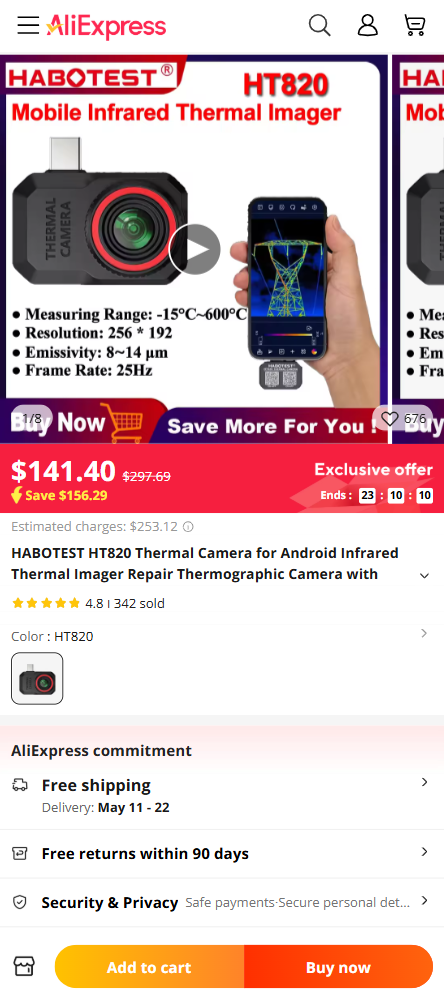 

There were other competing products in somewhat higher price range that came with optional macro lens for PCB inspection, but I went with the cheapest option anyway to try my luck.

# Using it on Android

Both TC001 app and the new TopInfrared app worked just fine:

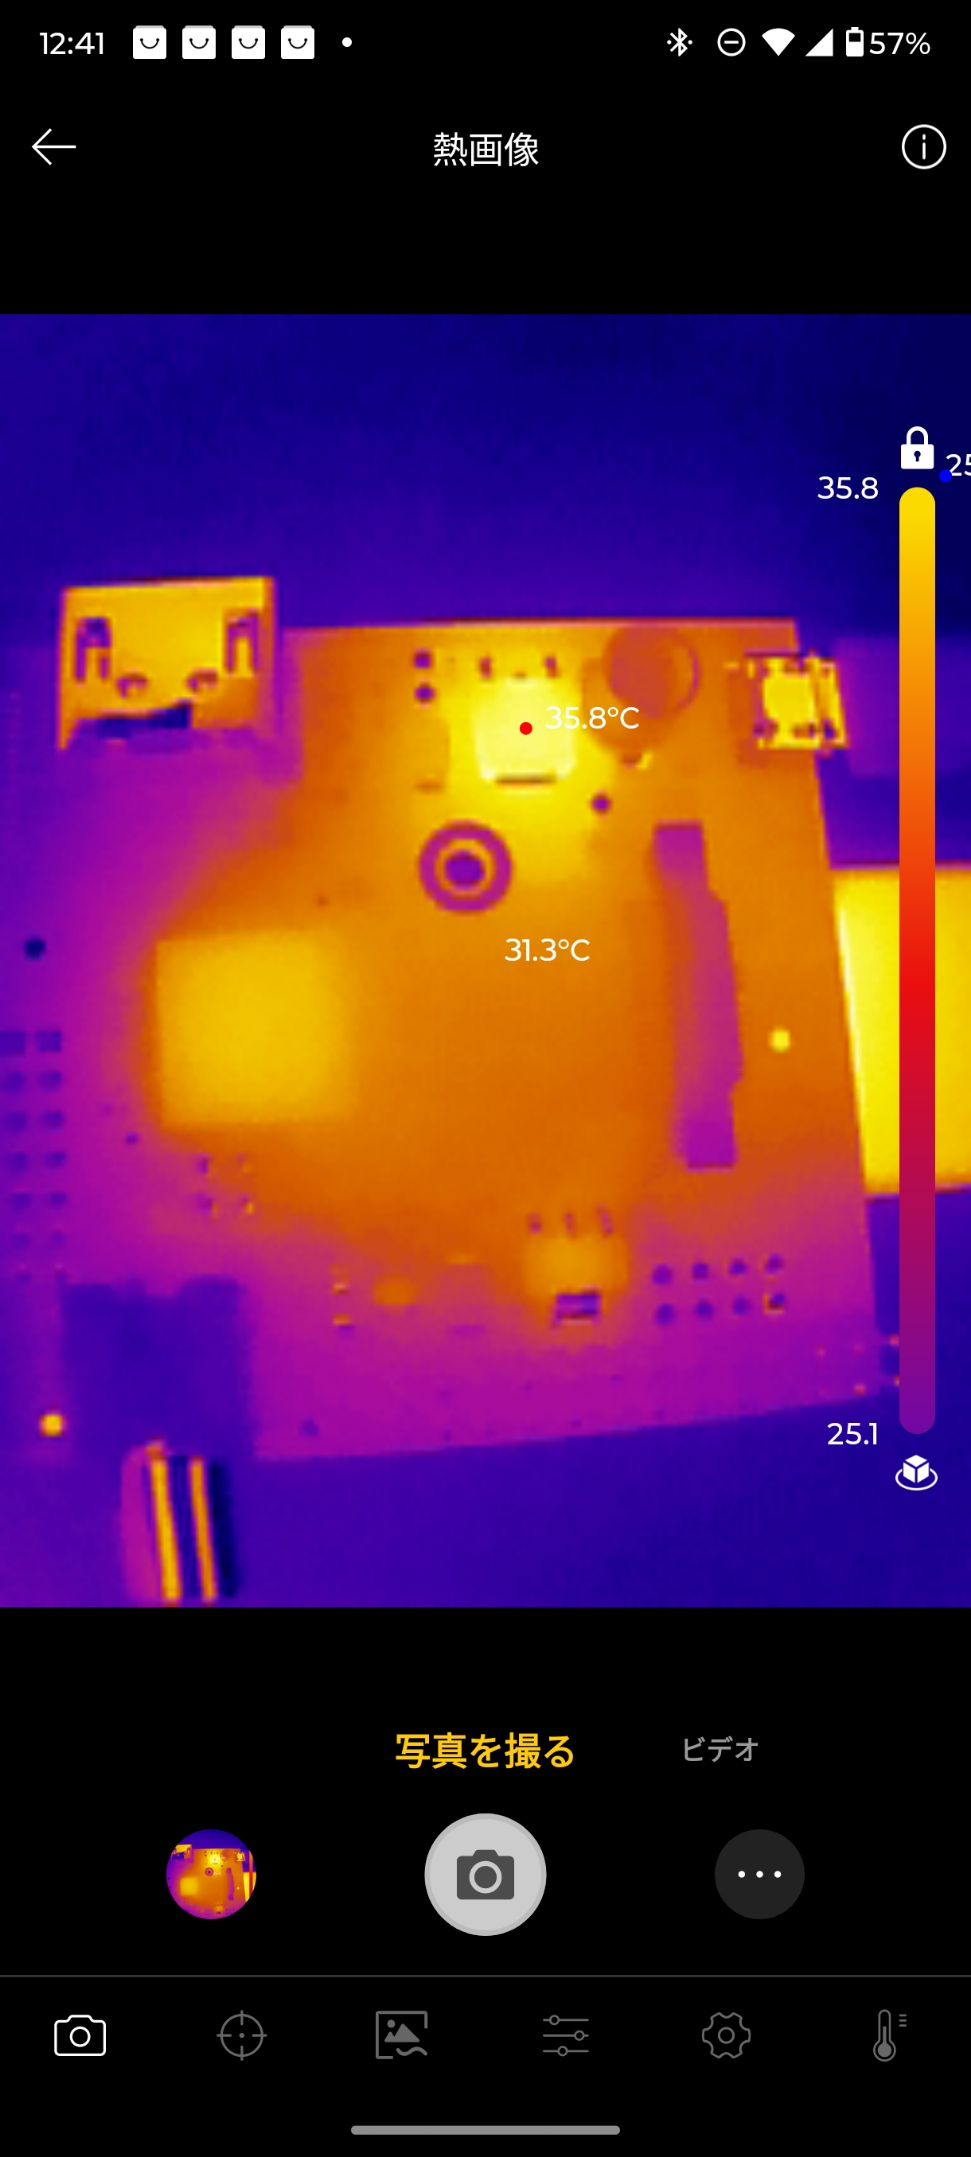 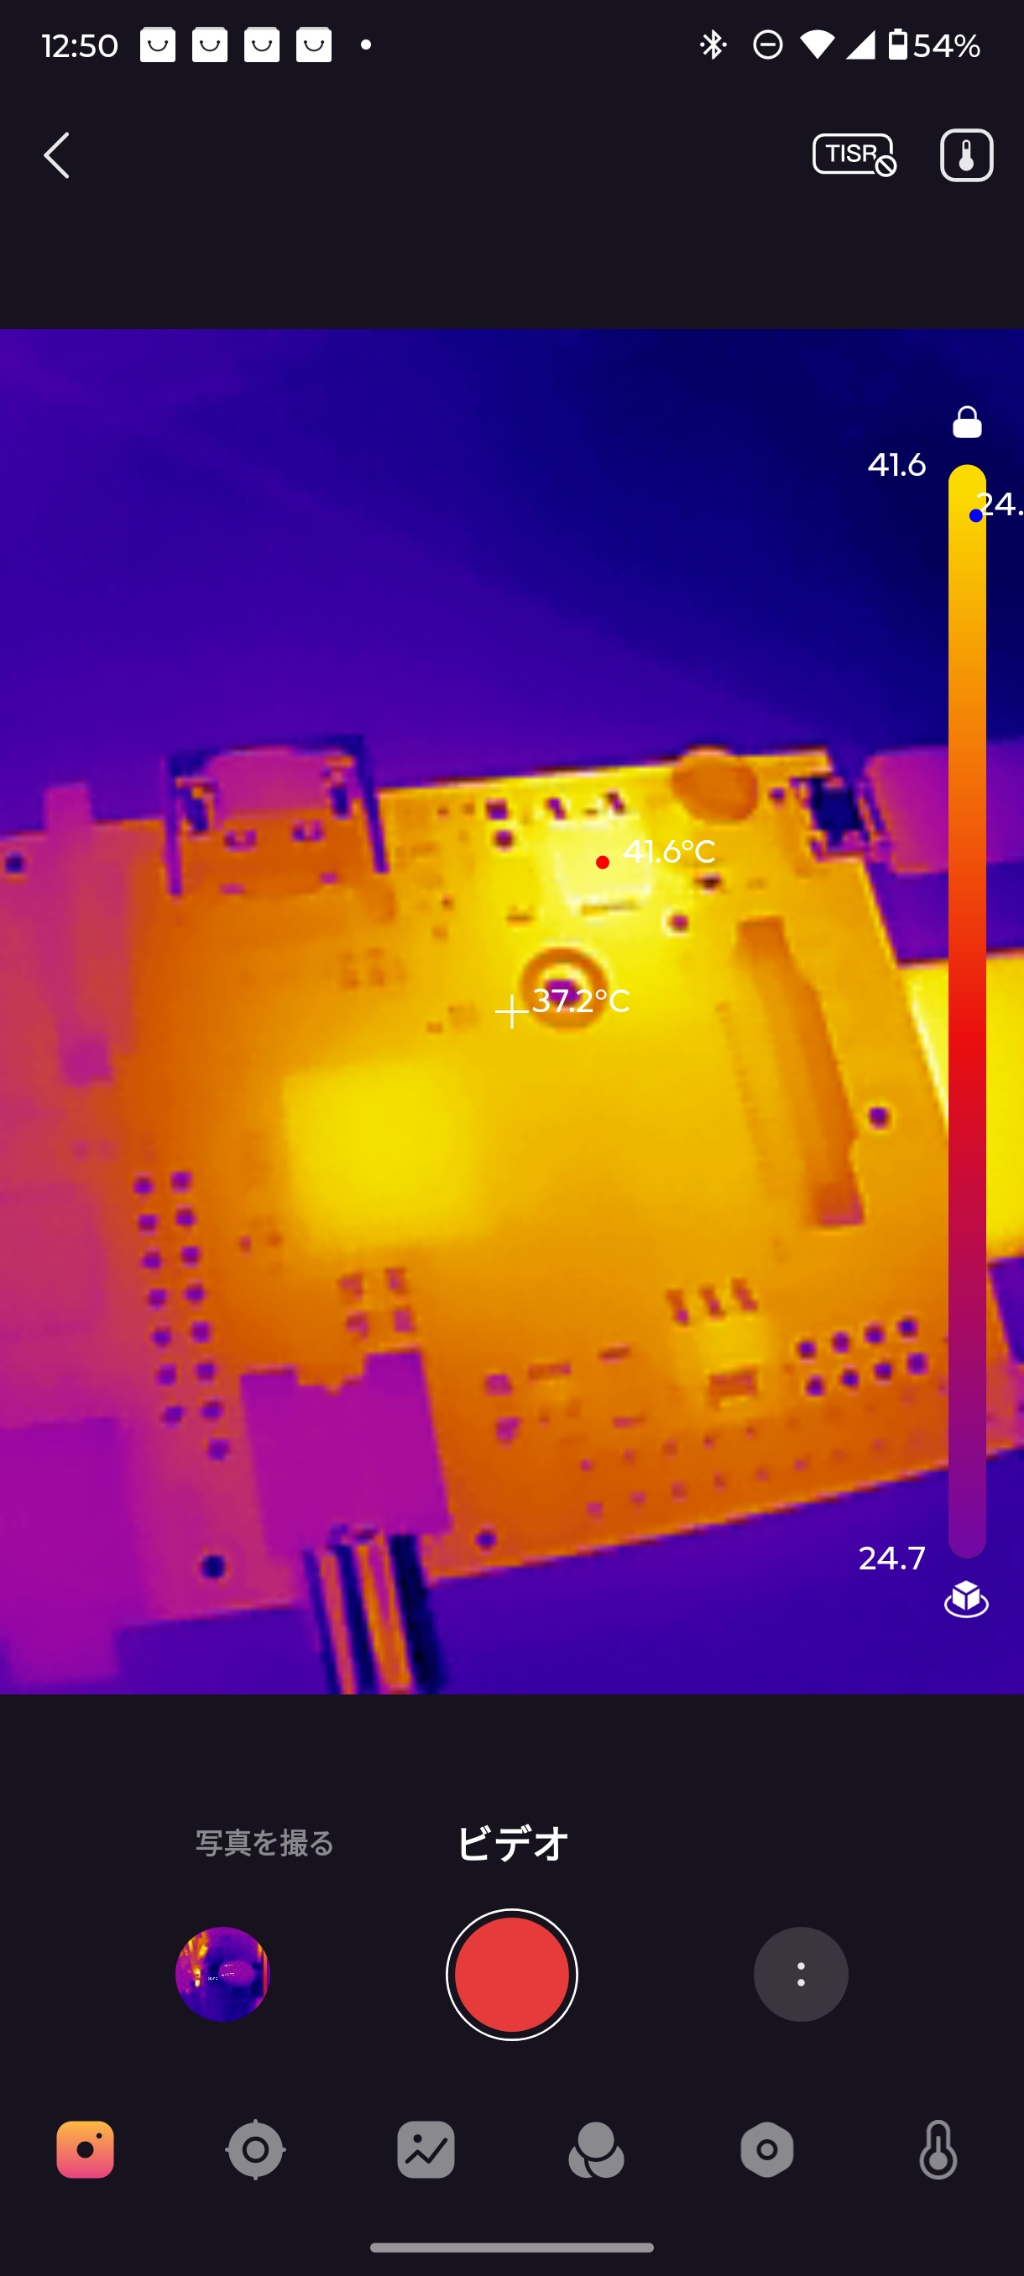

# Using it on Windows

TCView app worked just fine:

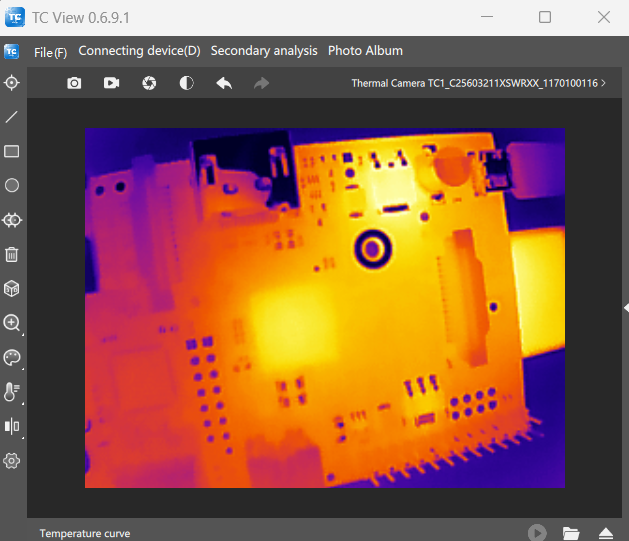

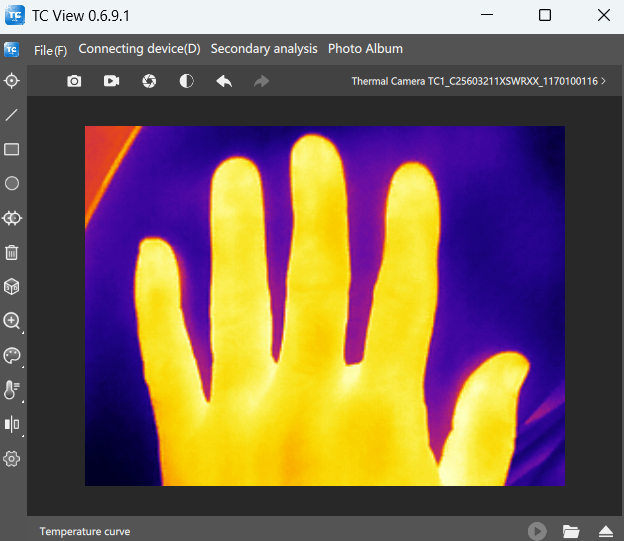

# Using a Macro Lens

For PCB inspection, I obtatined cheap (5-10USD/each) PVD focusing lens used for laser cutting.
I wanted to see difference in performance/usability, so I got two lens:

- 12mm diameter, 25.4mm focal length (~5USD)
- 20mm diameter, 50.8mm focal length (~10USD)

Both lens seem to work well and I was able to get much closer to the PCB. I actually like 12mm one as it fits cleanly into the case.

Note that all screenshots are taken while hand-holding the PCB. Actual results were even better as it caused image getting somewhat out of focus while trying to take these screenshots.

## Using 12mm diameter lens
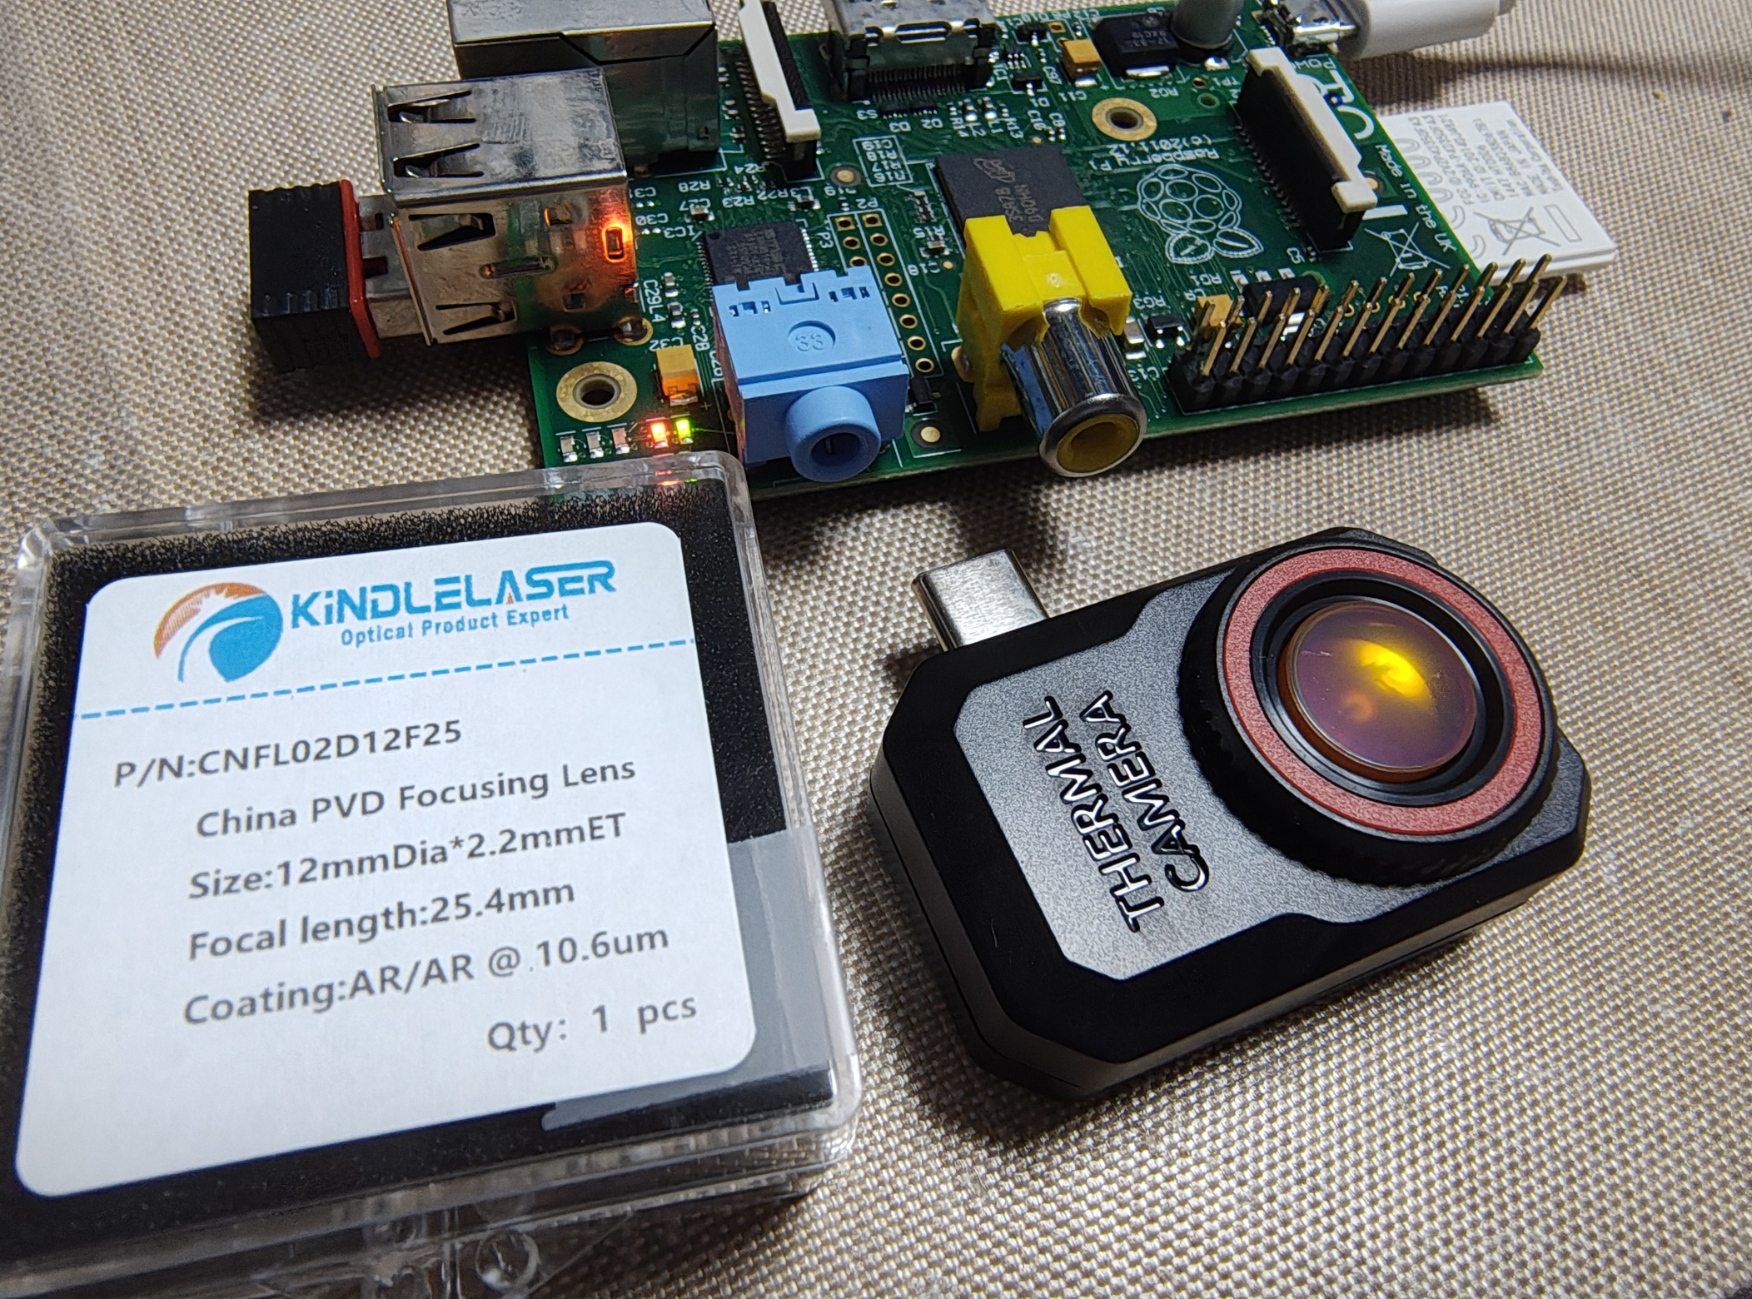

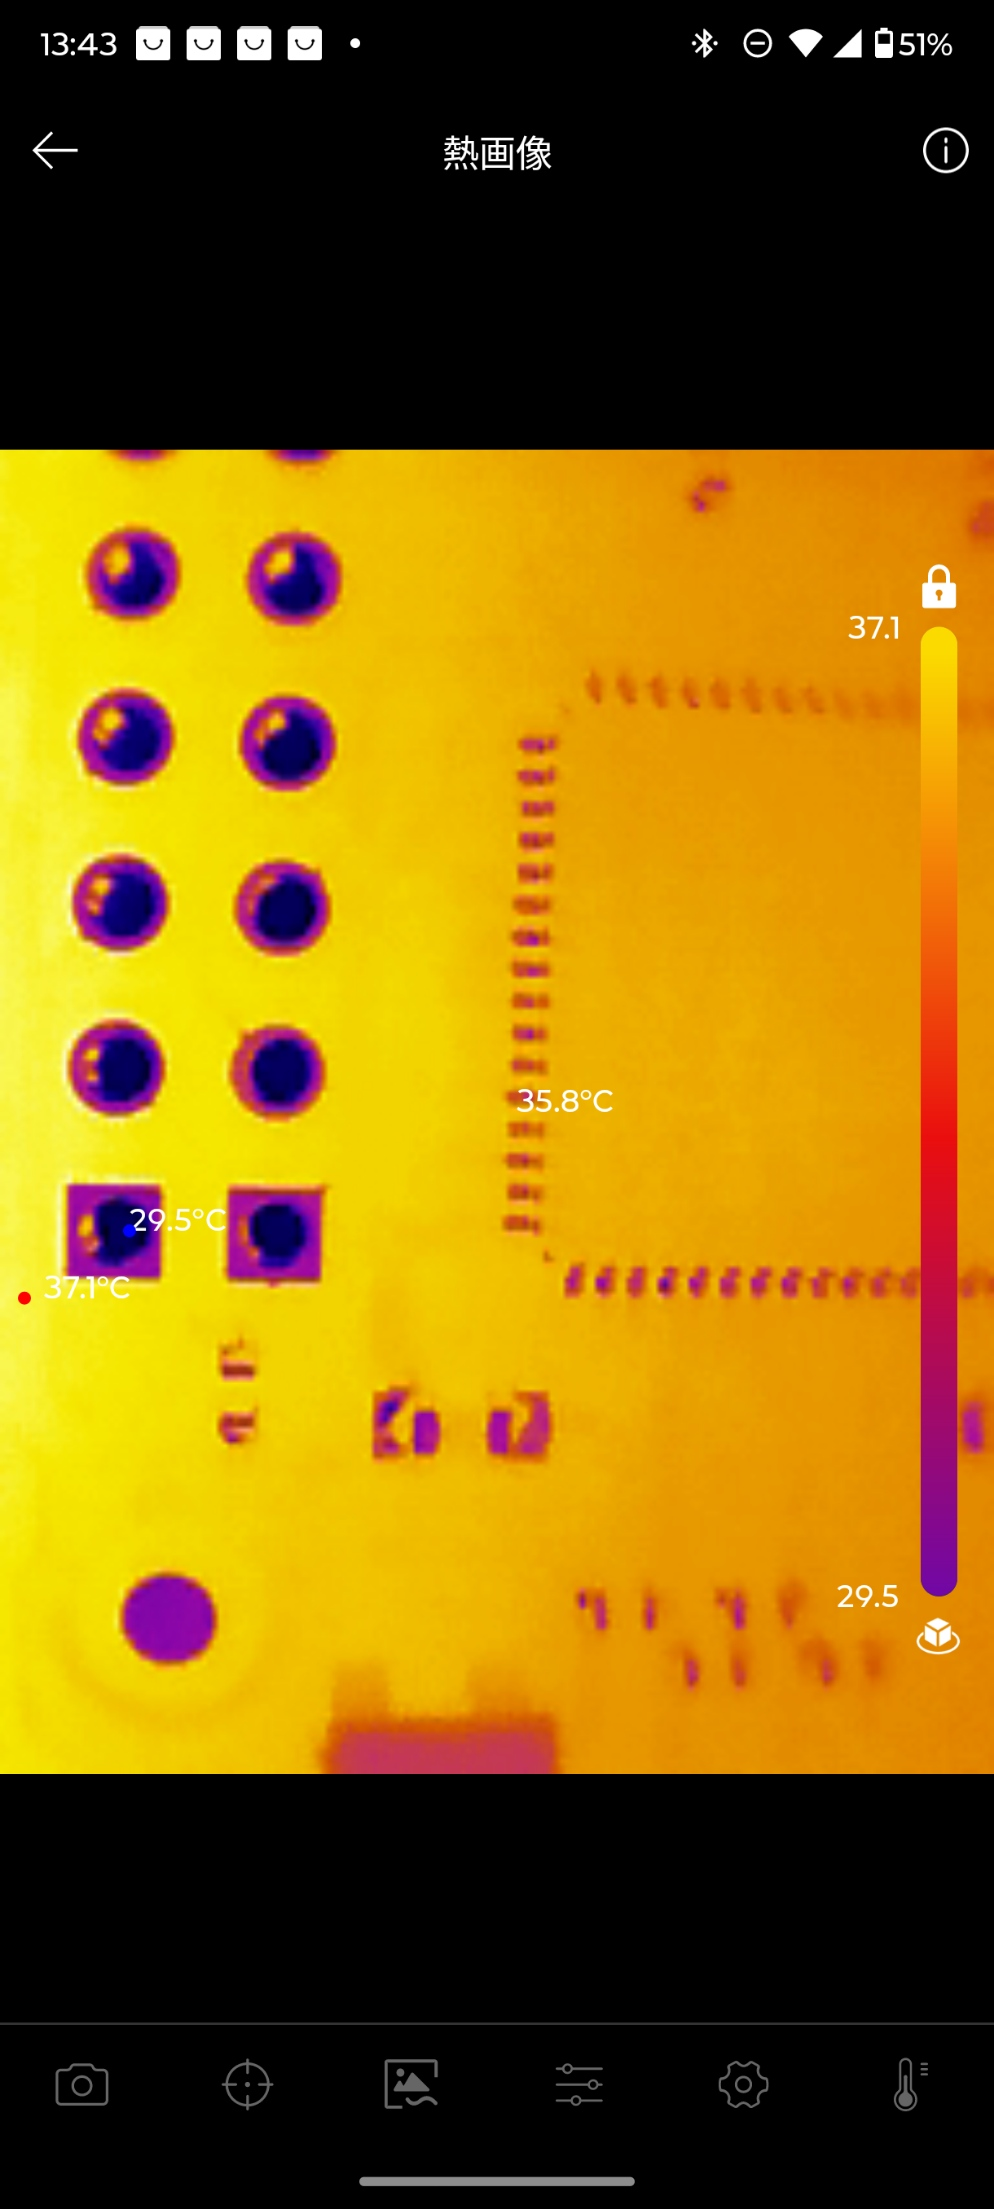

## Using 20mm diameter lens
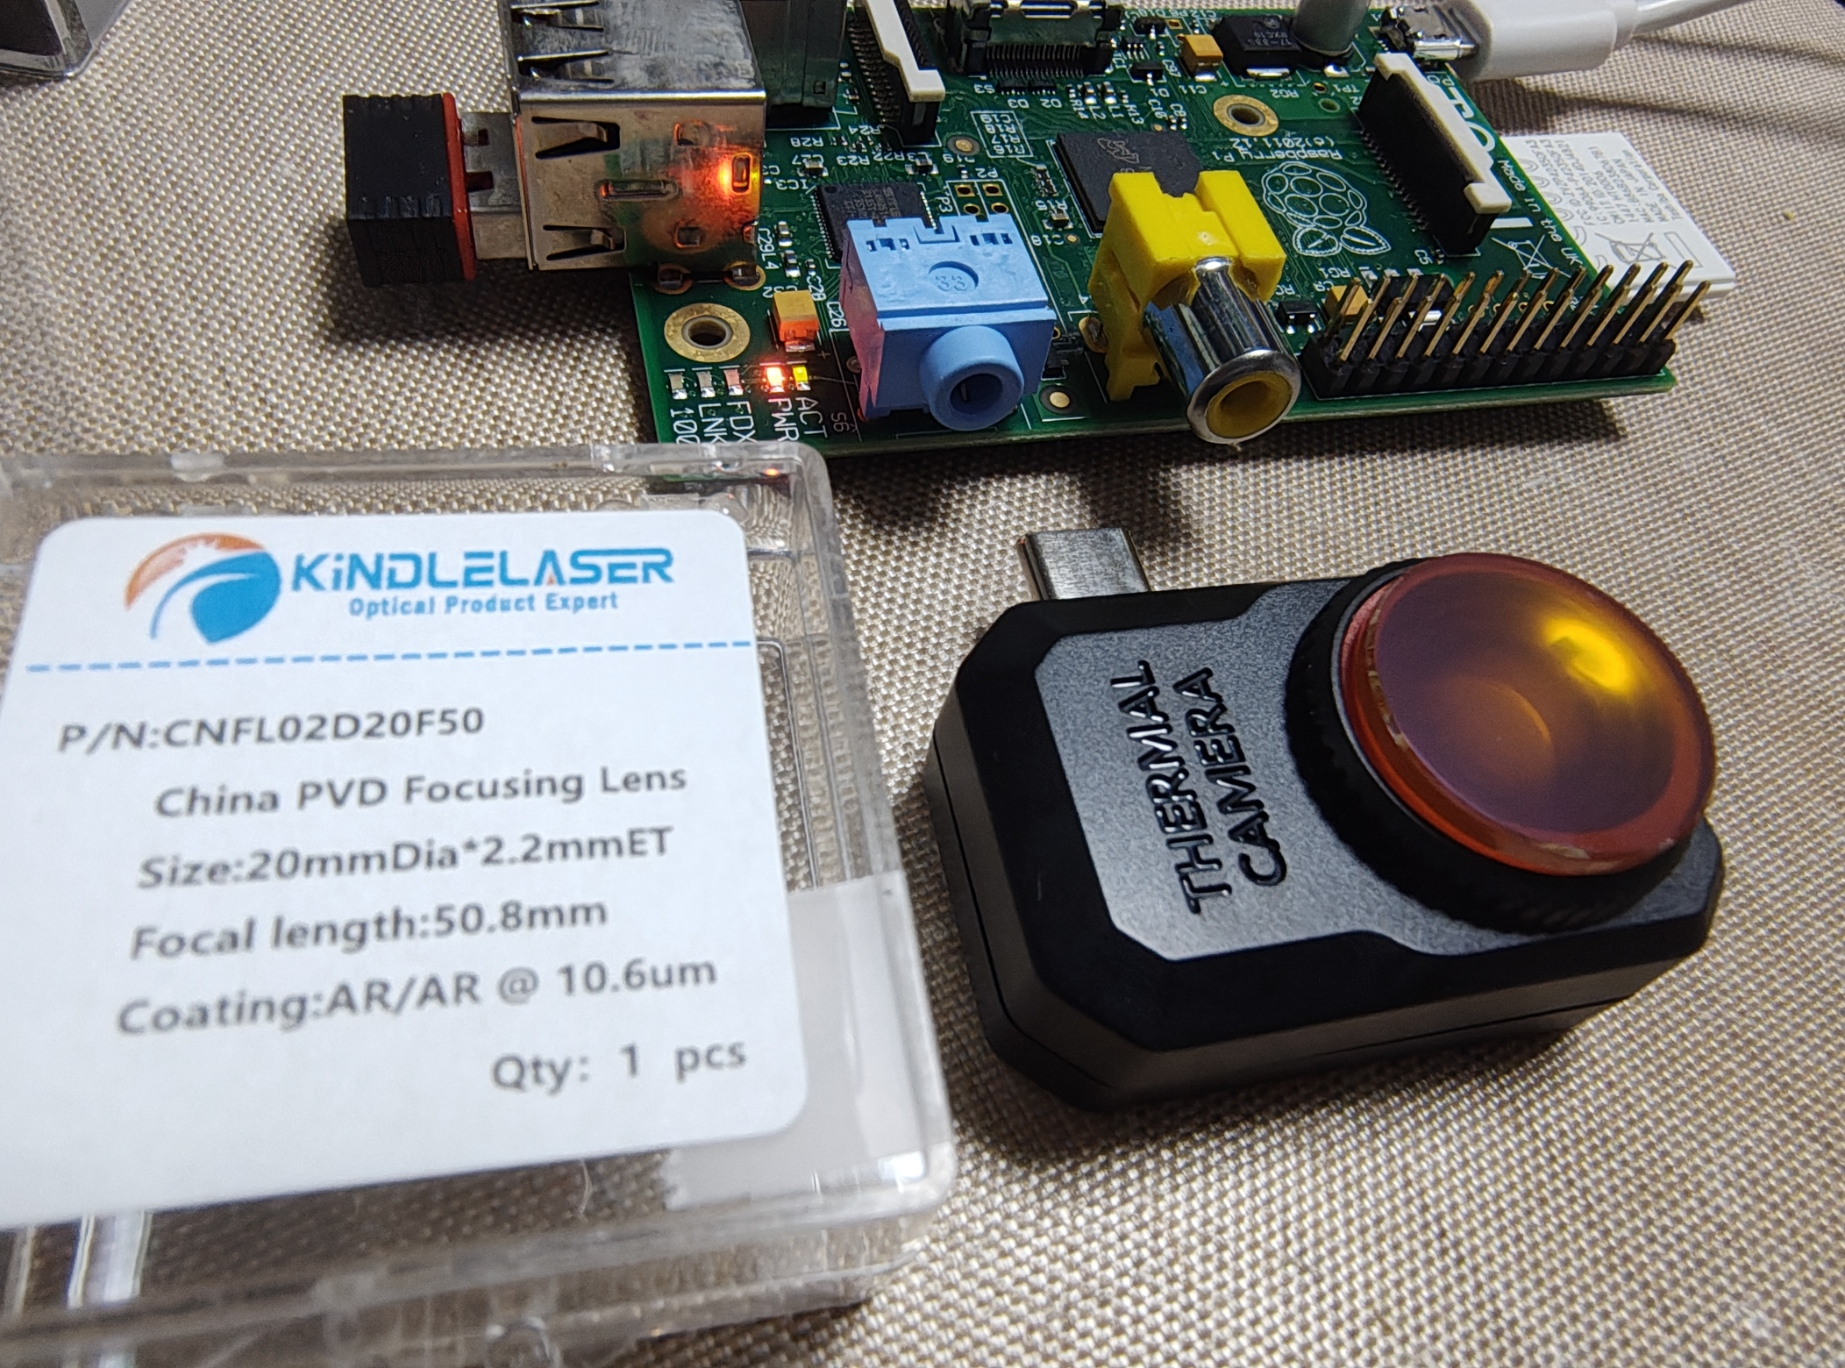

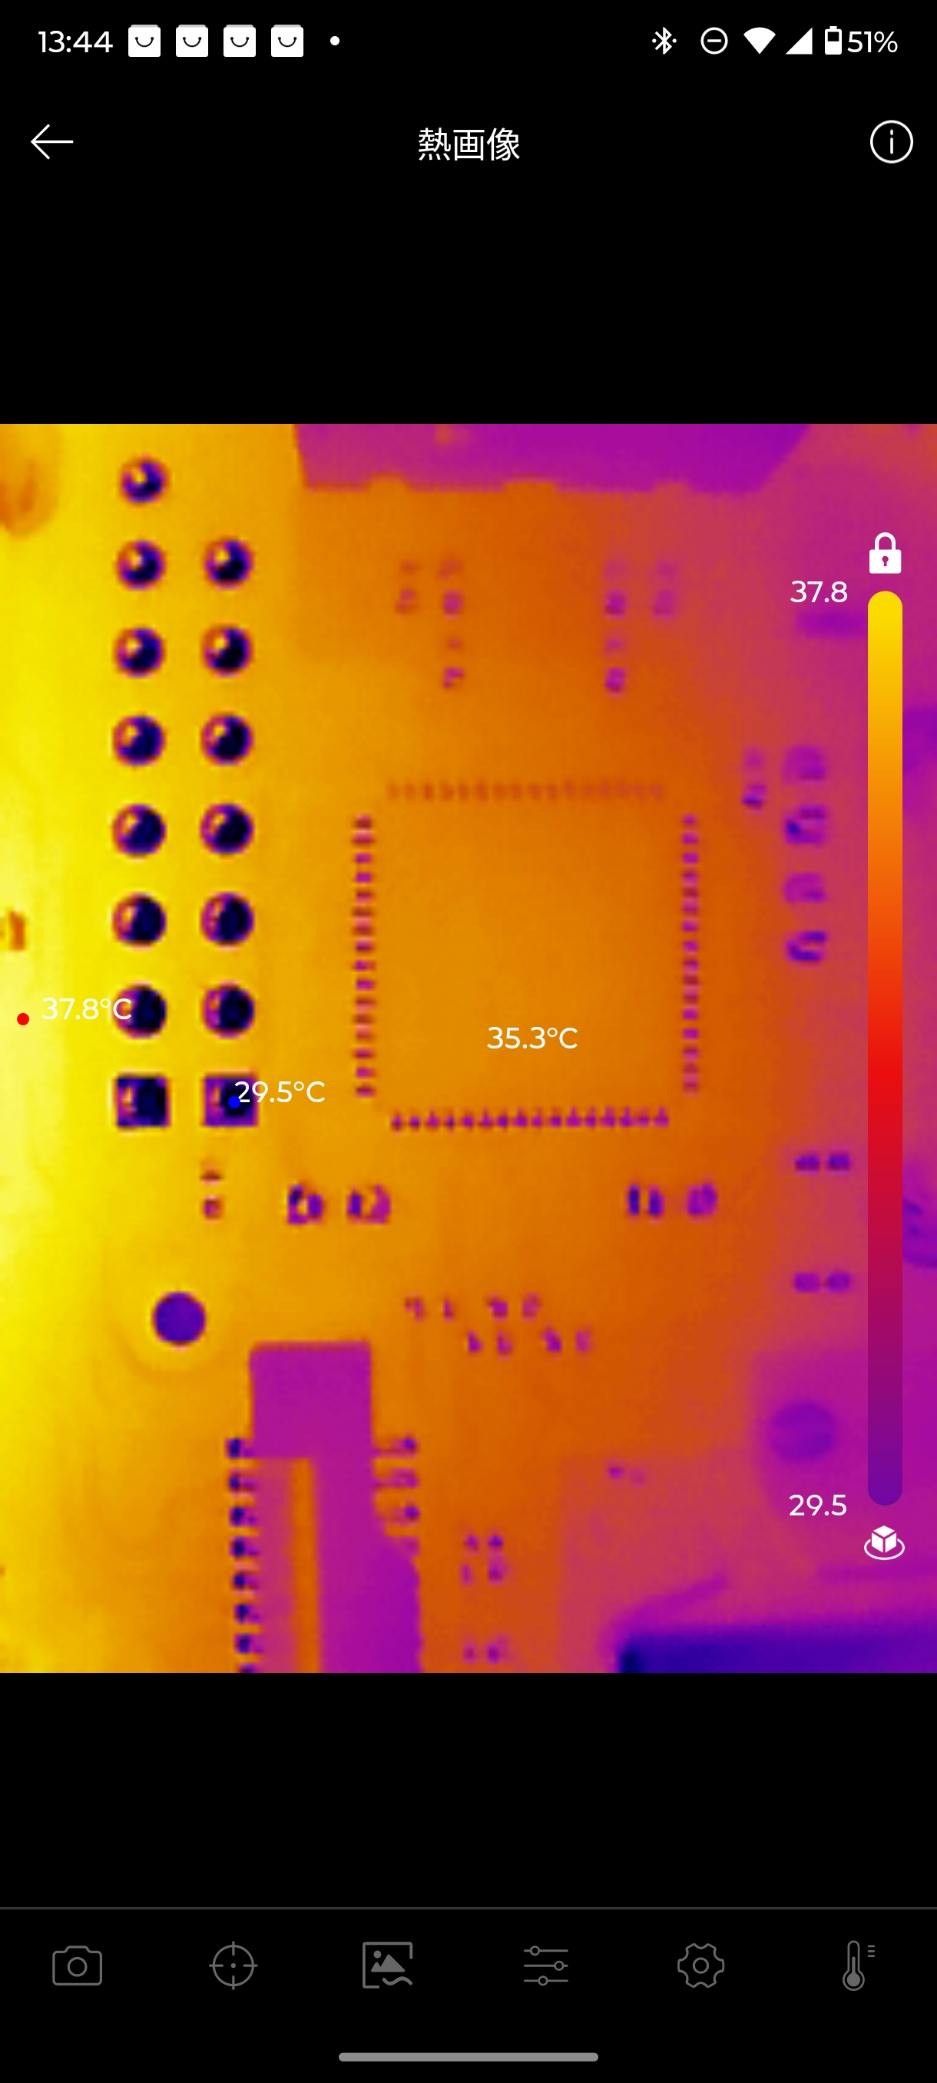


# Using it on Linux

While it behaves like a standard UVC Camera, I had to enable several additional kernel module parameters to get it working. Without it, frame readout from the device caused a timeout error.

```
modprobe uvcvideo nodrop=1 timeout=5000 quirks=0x80
```

Also, while I can capture a frame, I haven't figured out how can I convert it into typical thermal capture image. I'm also trying [leswright1977/PyThermalCamera: Python Software to use the Topdon TC001 Thermal Camera on Linux and the Raspberry Pi](https://github.com/leswright1977/PyThermalCamera), but it's not working for me so far.

## Device Access on Linux

In [176]:
! lsusb

Bus 001 Device 008: ID 0bda:5840 Realtek Semiconductor Corp. USB Camera
Bus 001 Device 001: ID 1d6b:0002 Linux Foundation 2.0 root hub
Bus 002 Device 002: ID 80ee:0021 VirtualBox USB Tablet
Bus 002 Device 001: ID 1d6b:0001 Linux Foundation 1.1 root hub


In [177]:
! v4l2-ctl --list-devices

USB Camera: USB Camera (usb-0000:00:0b.0-1):
	/dev/video0
	/dev/video1
	/dev/media0



In [178]:
! v4l2-ctl -d /dev/video0 --all

Driver Info:
	Driver name      : uvcvideo
	Card type        : USB Camera: USB Camera
	Bus info         : usb-0000:00:0b.0-1
	Driver version   : 5.10.191
	Capabilities     : 0x84a00001
		Video Capture
		Metadata Capture
		Streaming
		Extended Pix Format
		Device Capabilities
	Device Caps      : 0x04200001
		Video Capture
		Streaming
		Extended Pix Format
Media Driver Info:
	Driver name      : uvcvideo
	Model            : USB Camera: USB Camera
	Serial           : 200901010001
	Bus info         : usb-0000:00:0b.0-1
	Media version    : 5.10.191
	Hardware revision: 0x00001303 (4867)
	Driver version   : 5.10.191
Interface Info:
	ID               : 0x03000002
	Type             : V4L Video
Entity Info:
	ID               : 0x00000001 (1)
	Name             : USB Camera: USB Camera
	Function         : V4L2 I/O
	Flags         : default
	Pad 0x01000007   : 0: Sink
	  Link 0x02000010: from remote pad 0x100000a of entity 'Extension 4': Data, Enabled, Immutable
Priority: 2
Video input : 0 (Input 1: o

In [179]:
! v4l2-ctl -d /dev/video1 --all

Driver Info:
	Driver name      : uvcvideo
	Card type        : USB Camera: USB Camera
	Bus info         : usb-0000:00:0b.0-1
	Driver version   : 5.10.191
	Capabilities     : 0x84a00001
		Video Capture
		Metadata Capture
		Streaming
		Extended Pix Format
		Device Capabilities
	Device Caps      : 0x04a00000
		Metadata Capture
		Streaming
		Extended Pix Format
Media Driver Info:
	Driver name      : uvcvideo
	Model            : USB Camera: USB Camera
	Serial           : 200901010001
	Bus info         : usb-0000:00:0b.0-1
	Media version    : 5.10.191
	Hardware revision: 0x00001303 (4867)
	Driver version   : 5.10.191
Interface Info:
	ID               : 0x03000005
	Type             : V4L Video
Entity Info:
	ID               : 0x00000004 (4)
	Name             : USB Camera: USB Camera
	Function         : V4L2 I/O
Priority: 2
Format Metadata Capture:
	Sample Format   : 'UVCH' (UVC Payload Header Metadata)
	Buffer Size     : 1024


In [180]:
! media-ctl -d /dev/media0 -p

Media controller API version 5.10.191

Media device information
------------------------
driver          uvcvideo
model           USB Camera: USB Camera
serial          200901010001
bus info        usb-0000:00:0b.0-1
hw revision     0x1303
driver version  5.10.191

Device topology
- entity 1: USB Camera: USB Camera (1 pad, 1 link)
            type Node subtype V4L flags 1
            device node name /dev/video0
	pad0: Sink
		<- "Extension 4":1 [ENABLED,IMMUTABLE]

- entity 4: USB Camera: USB Camera (0 pad, 0 link)
            type Node subtype V4L flags 0
            device node name /dev/video1

- entity 8: Extension 4 (2 pads, 2 links)
            type V4L2 subdev subtype Unknown flags 0
	pad0: Sink
		<- "Processing 2":1 [ENABLED,IMMUTABLE]
	pad1: Source
		-> "USB Camera: USB Camera":0 [ENABLED,IMMUTABLE]

- entity 11: Processing 2 (2 pads, 2 links)
             type V4L2 subdev subtype Unknown flags 0
	pad0: Sink
		<- "Input 1":0 [ENABLED,IMMUTABLE]
	pad1: Source
		-> "Extension 4"

# Accessing with OpenCV

In [187]:
import sys
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

In [183]:
# (re)open device
if cap and cap.isOpened():
  cap.release()
cap = cv2.VideoCapture(0)
cap.isOpened()

True

In [184]:
# check supported properties
pt = {}
for i in dir(cv2):
  if not i.startswith("CAP_PROP_"): continue
  ret = cap.get(cv2.__getattribute__(i))
  if ret != -1:
    pt[i] = ret
pt

{'CAP_PROP_AUTO_WB': 1.0,
 'CAP_PROP_BACKEND': 200.0,
 'CAP_PROP_BACKLIGHT': 0.0,
 'CAP_PROP_BRIGHTNESS': 0.0,
 'CAP_PROP_BUFFERSIZE': 4.0,
 'CAP_PROP_CONTRAST': 50.0,
 'CAP_PROP_CONVERT_RGB': 1.0,
 'CAP_PROP_FORMAT': 0.0,
 'CAP_PROP_FOURCC': 1448695129.0,
 'CAP_PROP_FPS': 25.0,
 'CAP_PROP_FRAME_HEIGHT': 384.0,
 'CAP_PROP_FRAME_WIDTH': 256.0,
 'CAP_PROP_GAMMA': 300.0,
 'CAP_PROP_HUE': 0.0,
 'CAP_PROP_MODE': 0.0,
 'CAP_PROP_POS_MSEC': 0.0,
 'CAP_PROP_SATURATION': 64.0,
 'CAP_PROP_SHARPNESS': 50.0,
 'CAP_PROP_TEMPERATURE': 4600.0,
 'CAP_PROP_WB_TEMPERATURE': 4600.0}

shape: (384, 256, 3)
bit/ch: uint8


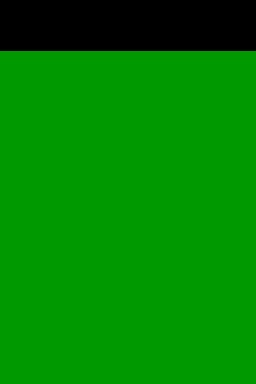

In [186]:
# Capture a frame

# Also seems to support capture of raw+thermal data
#cap.set(cv2.CAP_PROP_CONVERT_RGB, 0.0)

ret, frame = cap.read()
if ret:
  print("shape:", frame.shape)
  print("bit/ch:", frame.dtype)

  _, buf = cv2.imencode('.jpg', frame)
  display(Image(data=buf.tobytes()))

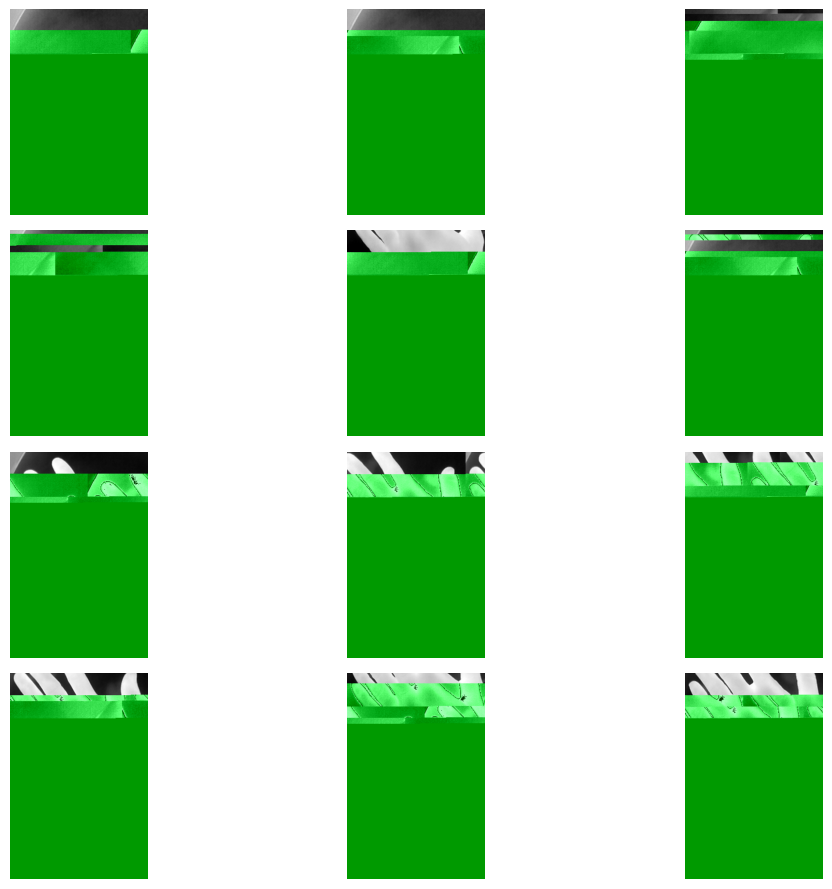

In [192]:
#
# Early captures seems to be bogus (device also makes a clicking sound
# for calibrarion), so read many frames to see how it changes
#

fig, axes = plt.subplots(4, 3, figsize=(12, 9))

for i, ax in enumerate(axes.flat):
  ret, frame = cap.read()
  if ret:
    ax.imshow(frame)
  ax.axis('off')
  time.sleep(0.1)

plt.tight_layout()
plt.show()